*Análisis estructural* <br>

## Análisis Modal
> **Tema:** Análisis de modal

*Autor:* *MiHR* <br>
*Contacto:* *mihrsozs@gmail.com*

In [149]:
import numpy as np
import sympy as sp

In [150]:
grav = 980.665 #cm/s2

#Peso en cada nivel
W1 = 0.707 #peso propio en primer nivel en kgf
W2 = 0.707 #peso propio en primer nivel en kgf
W3 = 0.627 #peso propio en primer nivel en kgf

Es = 2100000 #módulo de elasticidad en kgf/cm2
I = 0.00025 #inercia en cm4
Lc = 20 #largo columna en cm
ncol = 4 #cantidad de columnas

#Rigidez en cada nivel
k1 = 12*Es*I*Lc**-3*ncol #kgf/cm
k2 = 12*Es*I*Lc**-3*ncol #kgf/cm
k3 = 12*Es*I*Lc**-3*ncol #kgf/cm

M = np.zeros((3,3), dtype=float)

M[0,0] =  W1/grav;  M[0,1] = 0;         M[0,2] = 0
M[1,0] =  0;        M[1,1] = W2/grav;   M[1,2] = 0
M[2,0] =  0;        M[2,1] = 0;         M[2,2] = W3/grav

m = sp.Matrix(M)
print('La matriz de masa: [kgf/cm]'); display(m)

La matriz de masa: [kgf/cm]


Matrix([
[0.000720939362575395,                  0.0,                  0.0],
[                 0.0, 0.000720939362575395,                  0.0],
[                 0.0,                  0.0, 0.000639362065537161]])

In [151]:
K = np.zeros((3,3), dtype=float)

K[0,0] =  k1+k2;    K[0,1] = -k2;     K[0,2] = 0
K[1,0] =  -k2;      K[1,1] = k2+k3;   K[1,2] = -k3
K[2,0] =  0;        K[2,1] = -k3;     K[2,2] = k3

k = sp.Matrix(K)
print('La matriz de rigidez axial es: [kgf/cm]'); display(k)

La matriz de rigidez axial es: [kgf/cm]


Matrix([
[  6.3, -3.15,   0.0],
[-3.15,   6.3, -3.15],
[  0.0, -3.15,  3.15]])

In [152]:
# 1. Resolver problema generalizado: K φ = λ M φ
A = np.linalg.solve(M, K)

# 2. Eigenvalores (λ = ω^2)
eigvals = np.linalg.eigvals(A)

# 3. Ordenar (y quedarnos con la parte real por seguridad numérica)
eigvals = np.real(eigvals)
eigvals_sorted = np.sort(eigvals)

# 4. Frecuencias angulares ω [rad/s]
omega = np.sqrt(eigvals_sorted)

# 5. Periodos T [s]
T = 2*np.pi / omega

# 6. Frecuencias f [Hz]
f = 1/T

print(f"Valores propios λ (ω²):\t\t\t{eigvals_sorted}:")
print(f"Frecuencias angulares ω [rad/s]:\t{omega}")
print(f"Periodos T [s]:\t\t\t\t{T}")
print(f"Frecuencias f [Hz]:\t\t\t{f}")

Valores propios λ (ω²):			[  921.6389  7091.5688 14390.7762]:
Frecuencias angulares ω [rad/s]:	[ 30.3585  84.2115 119.9616]
Periodos T [s]:				[0.207  0.0746 0.0524]
Frecuencias f [Hz]:			[ 4.8317 13.4027 19.0925]


In [153]:
from scipy.linalg import eigh
# 1. Resolver problema generalizado
eigvals, eigvecs = eigh(K, M)

# 2. Ordenar (eigh ya los entrega ordenados, pero por seguridad)
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# 3. Filtrar modos físicos
mask = eigvals > 0
eigvals = eigvals[mask]
eigvecs = eigvecs[:, mask]

# 4. Normalización: primer DOF = 1
phi = np.zeros_like(eigvecs)

for i in range(eigvecs.shape[1]):
    v = eigvecs[:, i]
    phi[:, i] = v / v[0]  # normaliza por el primer componente

# --- OUTPUT ---
print("Eigenvalores (λ = ω²):")
print(eigvals)

print("\nVectores propios (V):")
print(eigvecs)

print("\nFormas modales normalizadas (Φ):")
print(phi)

Eigenvalores (λ = ω²):
[  921.6389  7091.5688 14390.7762]

Vectores propios (V):
[[ 12.7774 -27.7997 -21.2365]
 [ 22.8596 -10.4793  27.4719]
 [ 28.1199  23.8495 -14.3014]]

Formas modales normalizadas (Φ):
[[ 1.      1.      1.    ]
 [ 1.7891  0.377  -1.2936]
 [ 2.2008 -0.8579  0.6734]]


In [154]:
import numpy as np
from scipy.linalg import eigh

# 1. Problema generalizado
eigvals, eigvecs = eigh(K, M)  # K φ = λ M φ

# 2. Ordenar (por seguridad)
idx = np.argsort(eigvals)
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# 3. Filtrar modos físicos
mask = eigvals > 0
eigvals = eigvals[mask]
eigvecs = eigvecs[:, mask]

# 4. Frecuencias y periodos
omega = np.sqrt(eigvals)       # [rad/s]
T = 2*np.pi / omega          # [s]
f = 1/T                      # [Hz]


# 5. Formas modales (normalización DOF1 = 1)
phi = np.zeros_like(eigvecs)
for i in range(eigvecs.shape[1]):
    v = eigvecs[:, i]
    phi[:, i] = v/v[0]

np.set_printoptions(precision=4, suppress=True)
print("=== RESULTADOS MODALES ===\n")

print("λ (ω²):")
print(eigvals)

print("\nω [rad/s]:")
print(omega)

print("\nT [s]:")
print(T)

print("\nf [Hz]:")
print(f)

print("\nVectores propios (V):")
print(eigvecs)

print("\nFormas modales Φ (DOF1 = 1):")
print(phi)

=== RESULTADOS MODALES ===

λ (ω²):
[  921.6389  7091.5688 14390.7762]

ω [rad/s]:
[ 30.3585  84.2115 119.9616]

T [s]:
[0.207  0.0746 0.0524]

f [Hz]:
[ 4.8317 13.4027 19.0925]

Vectores propios (V):
[[ 12.7774 -27.7997 -21.2365]
 [ 22.8596 -10.4793  27.4719]
 [ 28.1199  23.8495 -14.3014]]

Formas modales Φ (DOF1 = 1):
[[ 1.      1.      1.    ]
 [ 1.7891  0.377  -1.2936]
 [ 2.2008 -0.8579  0.6734]]


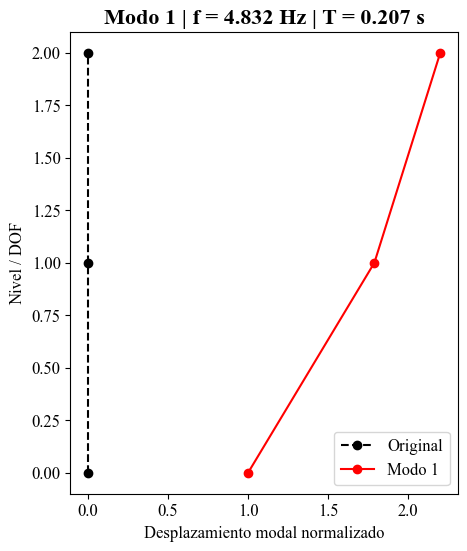

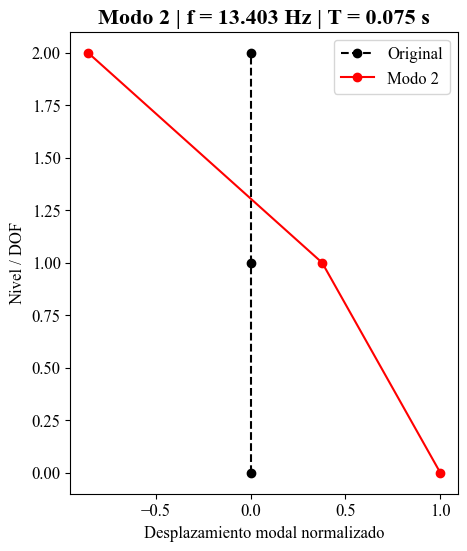

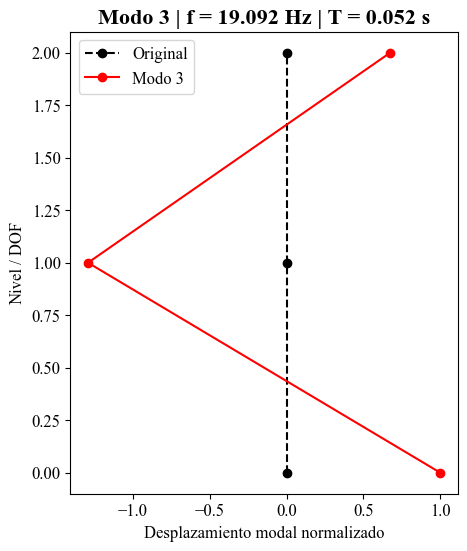

In [155]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'Times New Roman' #Times New Roman
plt.rcParams.update({'font.size': 12}) 

# Coordenadas verticales de los pisos o GDL
z = np.arange(0, phi.shape[0])

scale = 1.0  # aumenta o reduce la deformada

for i in range(phi.shape[1]):
    x_original = np.zeros_like(z)
    x_deformada = scale * phi[:, i]

    plt.figure(figsize=(5, 6))

    plt.plot(x_original, z, color='k', marker="o", linestyle="--", label="Original")
    plt.plot(x_deformada, z, color='red', marker="o", label=f"Modo {i+1}")

    plt.xlabel("Desplazamiento modal normalizado")
    plt.ylabel("Nivel / DOF")
    plt.title(f"Modo {i+1} | f = {f[i]:.3f} Hz | T = {T[i]:.3f} s", fontsize=16, fontweight='bold')

    #plt.grid(True)
    plt.legend()
    plt.show()